## 1. Import Libraries & Load Raw Data

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import optuna
# from optuna.pruners import MedianPruner
# from optuna.samplers import TPESampler

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


✓ All libraries imported successfully (including Optuna)


In [ ]:
df = pd.read_csv('train_data.csv')
print(f"Raw dataset shape: {df.shape}")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print(f"\n--- Data Types ---")
print(df.dtypes.value_counts())

print(f"\n--- First few rows ---")
print(df.head())

Raw dataset shape: (11357, 78)
Total rows: 11357
Total columns: 78

--- Data Types ---
bool       35
object     23
int64      18
float64     2
Name: count, dtype: int64

--- First few rows ---
   QueryID  ResponseID                  QueryName               ResponseName  \
0       10          10             Counter-Strike             Counter-Strike   
1       20          20      Team Fortress Classic      Team Fortress Classic   
2       30          30              Day of Defeat              Day of Defeat   
3       40          40         Deathmatch Classic         Deathmatch Classic   
4       50          50  Half-Life: Opposing Force  Half-Life: Opposing Force   

  ReleaseDate  RequiredAge  DemoCount  DeveloperCount  DLCCount  Metacritic  \
0  Nov 1 2000            0          0               1         0          88   
1  Apr 1 1999            0          0               1         0           0   
2  May 1 2003            0          0               1         0          79   
3  Jun 1 2

## 2. Exploratory Data Analysis (EDA)

In [ ]:
print(f"\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'RecommendationCount' in numeric_cols:
    numeric_cols.remove('RecommendationCount')
    
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

correlations = df[numeric_cols].corrwith(df['RecommendationCount']).sort_values(ascending=False)
print(f"\n--- Top 20 Features Correlated with Target ---")
print(correlations.head(20))


--- Missing Values ---
              Missing_Count  Percentage
Website                2713   23.888351
SupportEmail              2    0.017610
QueryName                 1    0.008805
SupportURL                1    0.008805
LegalNotice               1    0.008805

Numeric features: 19
Categorical features: 23

--- Top 20 Features Correlated with Target ---
SteamSpyPlayersEstimate        0.669003
SteamSpyOwners                 0.641550
SteamSpyPlayersVariance        0.497796
SteamSpyOwnersVariance         0.430400
MovieCount                     0.163591
Metacritic                     0.124709
AchievementCount               0.119373
RequiredAge                    0.078238
ScreenshotCount                0.062586
PackageCount                   0.050747
AchievementHighlightedCount    0.047482
PriceFinal                     0.046995
PriceInitial                   0.044216
DLCCount                       0.036923
PublisherCount                 0.025884
DeveloperCount                 0.021836
D

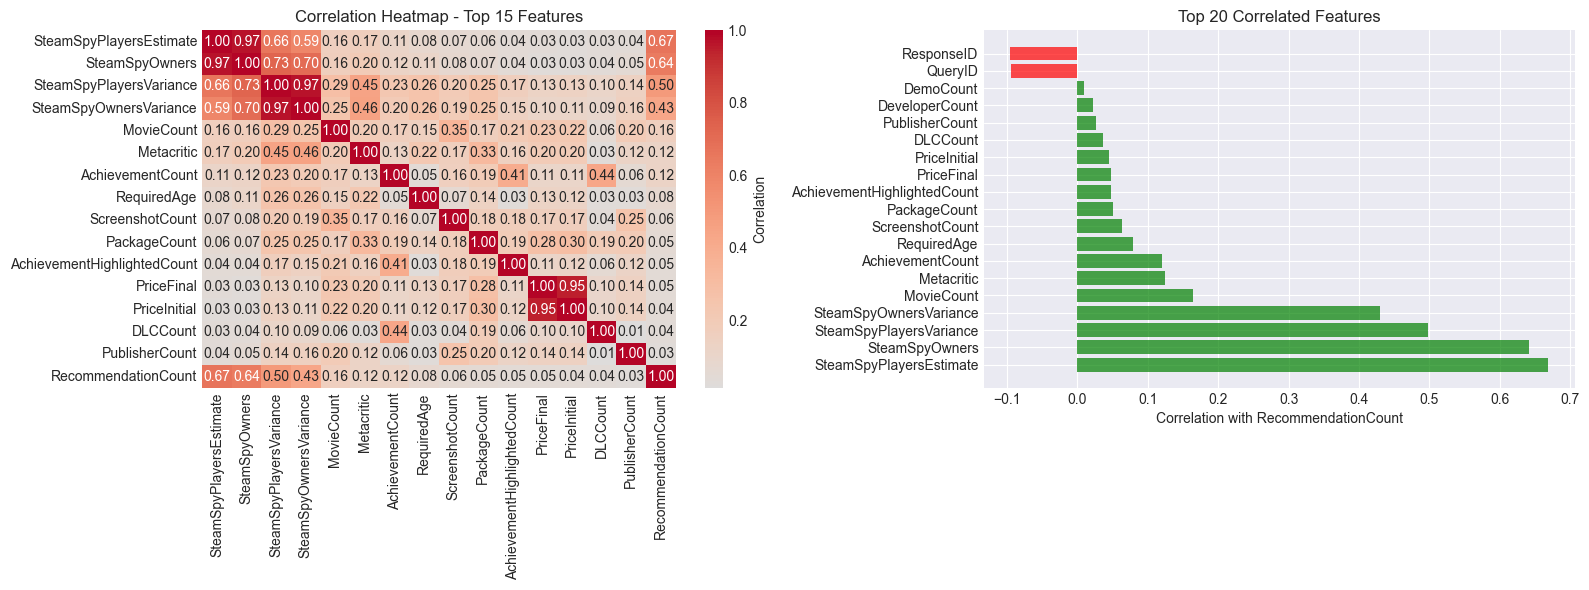

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_corr_features = correlations.head(15).index.tolist()
corr_matrix = df[top_corr_features + ['RecommendationCount']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Heatmap - Top 15 Features')

top_20_corr = correlations.head(20)
colors = ['green' if x > 0 else 'red' for x in top_20_corr.values]
axes[1].barh(range(len(top_20_corr)), top_20_corr.values, color=colors, alpha=0.7)
axes[1].set_yticks(range(len(top_20_corr)))
axes[1].set_yticklabels(top_20_corr.index)
axes[1].set_xlabel('Correlation with RecommendationCount')
axes[1].set_title('Top 20 Correlated Features')

plt.tight_layout()
plt.show()

## 3. Data Engineering & Feature Creation

In [ ]:
df_processed = df.copy()

text_cols = ['ShortDescrip', 'DetailedDescrip', 'AboutText']
text_cols = [col for col in text_cols if col in df_processed.columns]

if text_cols:
    for col in text_cols:
        df_processed[f'{col}_length'] = df_processed[col].fillna('').str.len()
        df_processed[f'{col}_word_count'] = df_processed[col].fillna('').str.split().str.len()
    
    combined_text = df_processed[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
    df_processed['total_text_length'] = combined_text.str.len()
    df_processed['total_word_count'] = combined_text.str.split().str.len()
    df_processed['has_website'] = (df_processed['Website'].fillna('') != '').astype(int)
    
    df_processed = df_processed.drop(columns=text_cols)
    print(f"✓ Created text-based features")

print(f"✓ Creating interaction features...")
interaction_pairs = [
    ('SteamSpyOwners', 'SteamSpyPlayersEstimate'),
    ('PriceFinal', 'Metacritic'),
    ('DLCCount', 'AchievementCount'),
    ('DeveloperCount', 'PublisherCount'),
]

for feat1, feat2 in interaction_pairs:
    if feat1 in df_processed.columns and feat2 in df_processed.columns:
        df_processed[f'{feat1}_x_{feat2}'] = df_processed[feat1] * df_processed[feat2]
        df_processed[f'{feat1}_div_{feat2}'] = np.where(
            df_processed[feat2] != 0, 
            np.log1p(df_processed[feat1]) / (np.log1p(df_processed[feat2]) + 1e-6),
            0
        )

category_cols = [col for col in df_processed.columns if col.startswith('Category')]
genre_cols = [col for col in df_processed.columns if col.startswith('Genre')]
platform_cols = [col for col in df_processed.columns if col.startswith('Platform')]
req_cols = [col for col in df_processed.columns if 'Reqs' in col]

df_processed['num_categories'] = df_processed[category_cols].sum(axis=1) if category_cols else 0
df_processed['num_genres'] = df_processed[genre_cols].sum(axis=1) if genre_cols else 0
df_processed['num_platforms'] = df_processed[platform_cols].sum(axis=1) if platform_cols else 0

skewed_features = ['SteamSpyOwners', 'SteamSpyPlayersEstimate', 'ScreenshotCount', 'DLCCount']
for feat in skewed_features:
    if feat in df_processed.columns:
        df_processed[f'{feat}_log'] = np.log1p(df_processed[feat])

id_url_cols = [col for col in df_processed.columns if any(x in col.lower() for x in ['id', 'url', 'email', 'image', 'background', 'header'])]
df_processed = df_processed.drop(columns=id_url_cols, errors='ignore')

print(f"\n--- Feature Engineering Complete ---")
print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_processed.shape}")
print(f"New features created: {df_processed.shape[1] - df.shape[1]}")

✓ Created text-based features
✓ Creating interaction features...

--- Feature Engineering Complete ---
Original shape: (11357, 78)
Processed shape: (11357, 93)
New features created: 15


## 4. Data Preprocessing & Preparation

In [ ]:
X = df_processed.drop(columns=['RecommendationCount'])
y = df_processed['RecommendationCount'].copy()

print(f"Initial shapes - X: {X.shape}, y: {y.shape}")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print(f"\nMissing values before imputation: {X.isnull().sum().sum()}")

if len(numeric_features) > 0:
    numeric_imputer = SimpleImputer(strategy='median')
    X[numeric_features] = numeric_imputer.fit_transform(X[numeric_features])

if len(categorical_features) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_features] = categorical_imputer.fit_transform(X[categorical_features])
    
    le_dict = {}
    for col in categorical_features:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

print(f"Missing values after imputation: {X.isnull().sum().sum()}")

y_log = np.log1p(y)

X.drop([])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, shuffle=True
)

print(f"\n--- Data Split ---")
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train target - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"Test target - Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

Initial shapes - X: (11357, 92), y: (11357,)
Numeric features: 41
Categorical features: 16

Missing values before imputation: 2715
Missing values after imputation: 0

--- Data Split ---
Train set: (9085, 92)
Test set: (2272, 92)
Train target - Mean: 2.3411, Std: 3.2256
Test target - Mean: 2.4492, Std: 3.2553


## 5. Train Base Models (XGBoost, CatBoost, LightGBM)

In [ ]:
best_lgbm = {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.03578886190304795, 'num_leaves': 75, 'min_child_samples': 12, 'subsample': 0.6365091879802328, 'colsample_bytree': 0.8720705909059081, 'reg_alpha': 0.000979063223376566, 'reg_lambda': 0.6744990139060916}
best_xgb = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.03426793970008585, 'subsample': 0.9870080762818, 'colsample_bytree': 0.9617515985369774, 'gamma': 3.2586495869873557, 'reg_alpha': 1.3828266265103555, 'reg_lambda': 0.07345936081248616, 'min_child_weight': 3}
best_catboost = {'iterations': 250, 'depth': 5, 'learning_rate': 0.0938946055722177, 'l2_leaf_reg': 0.0004334602326023971, 'border_count': 213, 'bagging_temperature': 0.13666624223861912, 'random_strength': 0.0061740888712205795}


In [ ]:
print("="*70)
print("TRAINING XGBoost MODEL")
print("="*70)

xgb_params = {
    'n_estimators': 800,
    'max_depth': 9,
    'learning_rate': 0.04,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'min_child_weight': 2,
    'gamma': 0.5,
    'reg_alpha': 0.6,
    'reg_lambda': 1.3,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

xgb_model = xgb.XGBRegressor(
    # **best_xgb,
    early_stopping_rounds=50
    )

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test = xgb_model.predict(X_test)

xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_pred_train))
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_r2_test = r2_score(y_test, xgb_pred_test)
xgb_mae_test = mean_absolute_error(y_test, xgb_pred_test)

print(f"✓ XGBoost trained")
print(f"  RMSE (Train): {xgb_rmse_train:.6f}")
print(f"  RMSE (Test):  {xgb_rmse_test:.6f}")
print(f"  MAE (Test):   {xgb_mae_test:.6f}")
print(f"  R² (Test):    {xgb_r2_test:.6f}")

TRAINING XGBoost MODEL
✓ XGBoost trained
  RMSE (Train): 0.865019
  RMSE (Test):  1.479588
  MAE (Test):   0.827787
  R² (Test):    0.793329


In [ ]:
print("\n" + "="*70)
print("TRAINING CatBoost MODEL")
print("="*70)

cb_params = {
    'iterations': 800,
    'learning_rate': 0.04,
    'depth': 8,
    'l2_leaf_reg': 3,
    'subsample': 0.85,
    'colsample_bylevel': 0.85,
    'bagging_temperature': 0.8,
    'random_strength': 0.5,
    'random_state': 42,
    'verbose': False,
    'task_type': 'CPU'
}

cb_model = cb.CatBoostRegressor(
    # **best_catboost
    )
cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=False
)

cb_pred_train = cb_model.predict(X_train)
cb_pred_test = cb_model.predict(X_test)

cb_rmse_train = np.sqrt(mean_squared_error(y_train, cb_pred_train))
cb_rmse_test = np.sqrt(mean_squared_error(y_test, cb_pred_test))
cb_r2_test = r2_score(y_test, cb_pred_test)
cb_mae_test = mean_absolute_error(y_test, cb_pred_test)

print(f"✓ CatBoost trained")
print(f"  RMSE (Train): {cb_rmse_train:.6f}")
print(f"  RMSE (Test):  {cb_rmse_test:.6f}")
print(f"  MAE (Test):   {cb_mae_test:.6f}")
print(f"  R² (Test):    {cb_r2_test:.6f}")


TRAINING CatBoost MODEL
✓ CatBoost trained
  RMSE (Train): 1.150480
  RMSE (Test):  1.450452
  MAE (Test):   0.829135
  R² (Test):    0.801389


In [ ]:
print("\n" + "="*70)
print("TRAINING LightGBM MODEL")
print("="*70)

lgb_params = {
    'n_estimators': 800,
    'max_depth': 9,
    'learning_rate': 0.04,
    'num_leaves': 100,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'min_child_samples': 20,
    'lambda_l1': 0.1,
    'lambda_l2': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

lgb_model = lgb.LGBMRegressor(
    # **best_lgbm,
    early_stopping_rounds=50
    )

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

lgb_pred_train = lgb_model.predict(X_train)
lgb_pred_test = lgb_model.predict(X_test)

lgb_rmse_train = np.sqrt(mean_squared_error(y_train, lgb_pred_train))
lgb_rmse_test = np.sqrt(mean_squared_error(y_test, lgb_pred_test))
lgb_r2_test = r2_score(y_test, lgb_pred_test)
lgb_mae_test = mean_absolute_error(y_test, lgb_pred_test)

print(f"✓ LightGBM trained")
print(f"  RMSE (Train): {lgb_rmse_train:.6f}")
print(f"  RMSE (Test):  {lgb_rmse_test:.6f}")
print(f"  MAE (Test):   {lgb_mae_test:.6f}")
print(f"  R² (Test):    {lgb_r2_test:.6f}")


TRAINING LightGBM MODEL
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8986
[LightGBM] [Info] Number of data points in the train set: 9085, number of used features: 89
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score 2.341115
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[97]	valid_0's l2: 2.11537
✓ LightGBM trained
  RMSE (Train): 1.009931
  RMSE (Test):  1.454432
  MAE (Test):   0.797969
  R² (Test):    0.800297


## 6. Build Stacking Ensemble Model

In [ ]:
print("\n" + "="*70)
print("BUILDING STACKING ENSEMBLE")
print("="*70)

base_models = [
    ('xgb', xgb.XGBRegressor(**xgb_params)),
    ('cb', cb.CatBoostRegressor(**cb_params)),
    ('lgb', lgb.LGBMRegressor(**lgb_params))
]

meta_learner = Ridge(alpha=1.0, random_state=42)

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5
)

print(f"Training stacking ensemble with base models: XGBoost, CatBoost, LightGBM")
print(f"Meta-learner: Ridge Regression")

stacking_model.fit(X_train, y_train)

stacking_pred_train = stacking_model.predict(X_train)
stacking_pred_test = stacking_model.predict(X_test)

stacking_rmse_train = np.sqrt(mean_squared_error(y_train, stacking_pred_train))
stacking_rmse_test = np.sqrt(mean_squared_error(y_test, stacking_pred_test))
stacking_r2_test = r2_score(y_test, stacking_pred_test)
stacking_mae_test = mean_absolute_error(y_test, stacking_pred_test)

print(f"\n✓ Stacking Ensemble trained")
print(f"  RMSE (Train): {stacking_rmse_train:.6f}")
print(f"  RMSE (Test):  {stacking_rmse_test:.6f}")
print(f"  MAE (Test):   {stacking_mae_test:.6f}")
print(f"  R² (Test):    {stacking_r2_test:.6f}")


BUILDING STACKING ENSEMBLE
Training stacking ensemble with base models: XGBoost, CatBoost, LightGBM
Meta-learner: Ridge Regression

✓ Stacking Ensemble trained
  RMSE (Train): 0.677375
  RMSE (Test):  1.416351
  MAE (Test):   0.779142
  R² (Test):    0.810618
